# Laparoscopic Surgical Video — Segmentation Dataset Preprocessing

**Project:** `D:\Study\CDC Project 1\Project`
**Task:** COCO instance-segmentation dataset (8 classes: anatomy + instruments) → clean, YOLO-seg ready dataset with domain-specific robustness augmentation.

**Hardware assumed:** Intel i7-14700HX, RTX 5060 8GB VRAM, 16GB RAM, Windows 11, everything installed on **D:** drive.

> **Updated paths (this version):** your raw data actually lives under
> `Project\Merged_Dataset\images` (13k+ frames) and
> `Project\Merged_Dataset\annotations` (contains the COCO json), **not**
> `data\raw\...` as in the original draft. This notebook has been corrected to
> point at `Merged_Dataset` directly. It also assumes your virtual environment
> is `.venv` (matching what's already on disk), and that you've **already**
> registered the `cdc-project` Jupyter kernel — that one-time step is marked
> done below and does not need to be re-run.

This notebook does **only the preprocessing that is actually needed** before you train YOLOv8/YOLOv11-seg:

1. Parse & sanity-check the COCO annotation file
2. Convert COCO → YOLO-seg label format
3. Group-aware train/val/test split (split by *video/case*, not by frame, to avoid data leakage between near-duplicate frames), with unannotated ("background") frames **capped at ~10% per split** so they don't dilute the training signal on rare classes
4. CLAHE illumination correction (generates a parallel `*_clahe` image set so you can A/B test with vs. without)
5. Domain-specific photometric augmentation: **smoke, glare, motion blur** simulation (classic OpenCV, no GAN) — applied *offline* to a controlled fraction of the **training split only**
6. `data.yaml` generation for Ultralytics YOLO
7. Visual sanity checks (polygon overlay, before/after augmentation grid)
8. A short **roadmap** section (not code you need to run now) pointing you to where CBAM/ECA, boundary-aware loss, focal loss, tiling, temporal smoothing and the baseline comparison plug into the *training* stage — those are model/training-time changes, not preprocessing, so they are intentionally not implemented here.

> Run cells top to bottom once. Re-running is safe — folders are recreated idempotently.


## 0. One-time environment setup (run in PowerShell, NOT in this notebook)

Everything below installs to **D:** — nothing touches your C: drive Python/pip cache.

Your `.venv` already exists and the `cdc-project` kernel is already registered, so
**steps 2 and 7 below are already done** — they're shown only for reference / in case
you ever need to rebuild the environment from scratch.

```powershell
# 1. Go to your project folder
cd "D:\Study\CDC Project 1\Project"

# 2. [ALREADY DONE] Create a virtual environment ON D: (yours is named .venv)
python -m venv .venv

# 3. Activate it
.\.venv\Scripts\activate

# 4. Force pip's cache onto D: as well (avoids filling your C: drive)
setx PIP_CACHE_DIR "D:\Study\CDC Project 1\Project\pip_cache"
set PIP_CACHE_DIR=D:\Study\CDC Project 1\Project\pip_cache

python -m pip install --upgrade pip

# 5. Install PyTorch with CUDA support for the RTX 5060 (Blackwell / sm_120).
#    As of 2026 the RTX 50-series needs a cu128 (or newer) build. Verify the
#    exact command for your CUDA driver at https://pytorch.org/get-started/locally/
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

# 6. Install the rest of the stack
pip install ultralytics opencv-python albumentations pycocotools ^
            scikit-image matplotlib tqdm pillow numpy ipykernel jupyter

# 7. [ALREADY DONE] Register this venv as a Jupyter kernel
python -m ipykernel install --user --name cdc-project --display-name "CDC Project (D:)"
```

**Verify GPU is visible** (run once venv is active):
```powershell
python -c "import torch; print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))"
```
If `cuda.is_available()` is `False`, your torch build doesn't match the driver — reinstall using the `cu128`/nightly command from the PyTorch site for your exact driver version.

In Jupyter, make sure **Kernel → Change kernel → CDC Project (D:)** is selected before running the cells below.


In [1]:
# ------------------------------------------------------------------
# 1. Paths & config — everything lives under the project root on D:
# ------------------------------------------------------------------
import os, re, json, random, glob, shutil
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Study\CDC Project 1\Project")

# --- Your actual raw data location (corrected) ---
MERGED_DATASET_DIR = PROJECT_ROOT / "Merged_Dataset"
RAW_IMAGES_DIR      = MERGED_DATASET_DIR / "images"        # 13k+ frames live here
RAW_ANNOTATIONS_DIR = MERGED_DATASET_DIR / "annotations"   # COCO json lives here

# Auto-detect the COCO json inside the annotations folder (don't hardcode a filename
# since it wasn't specified). If there are multiple .json files, edit RAW_COCO_JSON
# manually below instead of relying on auto-detection.
_json_candidates = sorted(RAW_ANNOTATIONS_DIR.glob("*.json"))
if len(_json_candidates) == 0:
    raise FileNotFoundError(
        f"No .json file found in {RAW_ANNOTATIONS_DIR} — put your COCO annotation "
        f"file there, or set RAW_COCO_JSON manually below."
    )
elif len(_json_candidates) > 1:
    print(f"WARNING: found {len(_json_candidates)} json files in {RAW_ANNOTATIONS_DIR}: "
          f"{[p.name for p in _json_candidates]}")
    print(f"Using the first one: {_json_candidates[0].name}. "
          f"If that's wrong, set RAW_COCO_JSON explicitly.")
RAW_COCO_JSON = _json_candidates[0]

# --- Output locations (created automatically) ---
YOLO_ROOT        = PROJECT_ROOT / "data" / "yolo"
IMG_TRAIN        = YOLO_ROOT / "images" / "train"
IMG_VAL          = YOLO_ROOT / "images" / "val"
IMG_TEST         = YOLO_ROOT / "images" / "test"
LBL_TRAIN        = YOLO_ROOT / "labels" / "train"
LBL_VAL          = YOLO_ROOT / "labels" / "val"
LBL_TEST         = YOLO_ROOT / "labels" / "test"

CLAHE_ROOT       = PROJECT_ROOT / "data" / "yolo_clahe"   # parallel CLAHE-corrected image set
AUG_TAG          = "aug"                                   # prefix for offline-augmented copies

SPLIT_RATIOS     = {"train": 0.8, "val": 0.15, "test": 0.05}
RANDOM_SEED      = 42
AUG_FRACTION     = 0.25   # fraction of TRAIN images to additionally augment (smoke/glare/blur), keep modest

# Images with ZERO annotations are kept as "background" (negative) examples, but capped
# at this fraction of each split so they don't drown out the (already rare) positive
# instances. Ultralytics recommends ~0-10% background images; 0.10 keeps some realistic
# "nothing visible" frames without diluting the rare-class signal. Set to 0.0 to drop
# all unannotated images, or 1.0 to keep all of them (old behavior).
BACKGROUND_TARGET_FRAC = 0.10

random.seed(RANDOM_SEED)

for p in [IMG_TRAIN, IMG_VAL, IMG_TEST, LBL_TRAIN, LBL_VAL, LBL_TEST,
          CLAHE_ROOT / "images" / "train", CLAHE_ROOT / "images" / "val", CLAHE_ROOT / "images" / "test",
          CLAHE_ROOT / "labels" / "train", CLAHE_ROOT / "labels" / "val", CLAHE_ROOT / "labels" / "test"]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Raw images   :", RAW_IMAGES_DIR)
print("Raw COCO json:", RAW_COCO_JSON)
print("Image count in raw folder:", len(list(RAW_IMAGES_DIR.glob('*'))))


Project root : D:\Study\CDC Project 1\Project
Raw images   : D:\Study\CDC Project 1\Project\Merged_Dataset\images
Raw COCO json: D:\Study\CDC Project 1\Project\Merged_Dataset\annotations\instances_train.json
Image count in raw folder: 12987


In [2]:
# ------------------------------------------------------------------
# 2. Imports (heavier libs only needed from here on)
# ------------------------------------------------------------------
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

try:
    from pycocotools import mask as maskUtils
    HAS_PYCOCOTOOLS = True
except ImportError:
    HAS_PYCOCOTOOLS = False
    print("pycocotools not installed — only polygon-format segmentations will be supported "
          "(fine for this dataset, but install pycocotools if you ever hit RLE masks).")


In [3]:
# ------------------------------------------------------------------
# 3. Load COCO annotations & quick EDA
# ------------------------------------------------------------------
with open(RAW_COCO_JSON, "r") as f:
    coco = json.load(f)

categories = {c["id"]: c["name"] for c in coco["categories"]}
# YOLO wants 0-indexed contiguous class ids, in a fixed, stable order
cat_ids_sorted = sorted(categories.keys())
cat_id_to_yolo = {cid: i for i, cid in enumerate(cat_ids_sorted)}
yolo_names     = [categories[cid] for cid in cat_ids_sorted]

print(f"Images      : {len(coco['images'])}")
print(f"Annotations : {len(coco['annotations'])}")
print(f"Classes ({len(yolo_names)}):")
for cid in cat_ids_sorted:
    print(f"  yolo_id={cat_id_to_yolo[cid]:>2}  coco_id={cid:>2}  name={categories[cid]}")

# class balance (instance count per class) — tells us if focal loss will actually be needed later
from collections import Counter
inst_counter = Counter(a["category_id"] for a in coco["annotations"])
print("\nInstances per class:")
for cid in cat_ids_sorted:
    print(f"  {categories[cid]:<25} {inst_counter.get(cid, 0)}")

images_by_id = {im["id"]: im for im in coco["images"]}
anns_by_image = {}
for a in coco["annotations"]:
    anns_by_image.setdefault(a["image_id"], []).append(a)

print(f"\nImages with at least one annotation: {len(anns_by_image)} / {len(coco['images'])}")


Images      : 12987
Annotations : 33001
Classes (8):
  yolo_id= 0  coco_id= 1  name=External Iliac Artery
  yolo_id= 1  coco_id= 2  name=External Iliac Vein
  yolo_id= 2  coco_id= 3  name=Obturator Nerve
  yolo_id= 3  coco_id= 4  name=Ovary
  yolo_id= 4  coco_id= 5  name=Ureter
  yolo_id= 5  coco_id= 6  name=Uterine Artery
  yolo_id= 6  coco_id= 7  name=Uterus
  yolo_id= 7  coco_id= 8  name=Instruments

Instances per class:
  External Iliac Artery     2659
  External Iliac Vein       1998
  Obturator Nerve           757
  Ovary                     2939
  Ureter                    438
  Uterine Artery            95
  Uterus                    9776
  Instruments               14339

Images with at least one annotation: 9648 / 12987


In [6]:
# ------------------------------------------------------------------
# 4. COCO -> YOLO-seg conversion
#    YOLO-seg label line: <class_id> x1 y1 x2 y2 ... xn yn   (all coords normalized 0-1)
#    A COCO annotation's "segmentation" can be:
#      - list[list[float]]   -> one or more polygons (a multi-part instance)
#      - dict {"counts":...} -> RLE mask (rare for this dataset, handled via pycocotools)
# ------------------------------------------------------------------

def rle_to_polygons(seg, h, w):
    # \"\"\"Decode an RLE mask to polygon(s) using contour extraction (fallback path).\"\"\"
    if not HAS_PYCOCOTOOLS:
        return []
    if isinstance(seg["counts"], list):
        rle = maskUtils.frPyObjects(seg, h, w)
    else:
        rle = seg
    m = maskUtils.decode(rle)
    contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in contours:
        if len(c) >= 3:
            polys.append(c.reshape(-1, 2).astype(float).flatten().tolist())
    return polys


def coco_ann_to_yolo_lines(ann, img_w, img_h):
    # \"\"\"Return a list of YOLO-seg label lines (one per polygon part) for a single COCO annotation.\"\"\"
    seg = ann.get("segmentation", None)
    if seg is None:
        return []

    yolo_cls = cat_id_to_yolo[ann["category_id"]]
    polygons = []

    if isinstance(seg, list):                      # polygon format
        polygons = seg
    elif isinstance(seg, dict):                     # RLE format
        polygons = rle_to_polygons(seg, img_h, img_w)

    lines = []
    for poly in polygons:
        if len(poly) < 6:          # need at least 3 points
            continue
        coords = np.array(poly, dtype=np.float64).reshape(-1, 2)
        coords[:, 0] = np.clip(coords[:, 0] / img_w, 0, 1)
        coords[:, 1] = np.clip(coords[:, 1] / img_h, 0, 1)
        flat = " ".join(f"{v:.6f}" for v in coords.flatten())
        lines.append(f"{yolo_cls} {flat}")
    return lines


def convert_all_to_yolo_labels(out_dir):
    # \"\"\"Write one .txt YOLO-seg label file per image (empty file if no annotations).\"\"\"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for img_id, im in tqdm(images_by_id.items(), desc="Converting COCO -> YOLO-seg"):
        w, h = im["width"], im["height"]
        stem = Path(im["file_name"]).stem
        lines = []
        for ann in anns_by_image.get(img_id, []):
            lines.extend(coco_ann_to_yolo_lines(ann, w, h))
        with open(out_dir / f"{stem}.txt", "w") as f:
            f.write("\n".join(lines))

# Convert into a staging folder first; we'll copy the right files into train/val/test next.
LABELS_STAGING = PROJECT_ROOT / "data" / "yolo_labels_all"
convert_all_to_yolo_labels(LABELS_STAGING)
print("YOLO-seg labels written to:", LABELS_STAGING)


Converting COCO -> YOLO-seg: 100%|██████████| 12987/12987 [00:04<00:00, 2699.03it/s]

YOLO-seg labels written to: D:\Study\CDC Project 1\Project\data\yolo_labels_all


In [7]:
# ------------------------------------------------------------------
# 5. Group-aware train/val/test split
#    Frames from the SAME surgical video (e.g. all "000frame_..." images) are highly
#    correlated (near-duplicate). Splitting frame-by-frame would leak the same case
#    into train AND val/test, giving an over-optimistic score. We split by the video
#    prefix in the filename instead (e.g. "000", "001", "002", ...), falling back to
#    `extra.name` if present in the COCO json.
# ------------------------------------------------------------------

def video_group_of(image_entry):
    name = image_entry.get("extra", {}).get("name", image_entry["file_name"])
    m = re.match(r"(\d+)frame", name)
    return m.group(1) if m else "unknown"

groups = {}
for im in coco["images"]:
    groups.setdefault(video_group_of(im), []).append(im)

group_ids = list(groups.keys())
random.shuffle(group_ids)

n = len(group_ids)
n_train = max(1, int(n * SPLIT_RATIOS["train"]))
n_val   = max(1, int(n * SPLIT_RATIOS["val"]))
train_groups = set(group_ids[:n_train])
val_groups   = set(group_ids[n_train:n_train + n_val])
test_groups  = set(group_ids[n_train + n_val:])

print(f"Video groups found: {n} -> train={len(train_groups)}  val={len(val_groups)}  test={len(test_groups)}")

split_of_image = {}
for gid, ims in groups.items():
    split = "train" if gid in train_groups else ("val" if gid in val_groups else "test")
    for im in ims:
        split_of_image[im["id"]] = split

split_counts = Counter(split_of_image.values())
print("Image counts per split:", dict(split_counts))


Video groups found: 9 -> train=7  val=1  test=1
Image counts per split: {'val': 742, 'test': 865, 'train': 11380}


In [8]:
# ------------------------------------------------------------------
# 6. Copy images + labels into data/yolo/{images,labels}/{train,val,test}
#
#    Images with ZERO annotations ("background" frames) are capped at
#    BACKGROUND_TARGET_FRAC of each split. This is done AFTER the group-based
#    split above, so which video a background frame belongs to still determines
#    which split it's eligible for -- we're only thinning them out within that
#    split, not moving them across splits (no leakage introduced).
# ------------------------------------------------------------------
dst_img = {"train": IMG_TRAIN, "val": IMG_VAL, "test": IMG_TEST}
dst_lbl = {"train": LBL_TRAIN, "val": LBL_VAL, "test": LBL_TEST}

# Bucket every image into annotated vs background, per split
annotated_ids_by_split  = {"train": [], "val": [], "test": []}
background_ids_by_split = {"train": [], "val": [], "test": []}

for img_id, im in images_by_id.items():
    split = split_of_image[img_id]
    if len(anns_by_image.get(img_id, [])) > 0:
        annotated_ids_by_split[split].append(img_id)
    else:
        background_ids_by_split[split].append(img_id)

# Solve for how many background images to keep so that
#   bg_kept / (annotated + bg_kept) == BACKGROUND_TARGET_FRAC
#   => bg_kept = annotated * target / (1 - target)
selected_background_ids_by_split = {}
for split in ["train", "val", "test"]:
    n_annotated    = len(annotated_ids_by_split[split])
    n_bg_available = len(background_ids_by_split[split])
    if BACKGROUND_TARGET_FRAC >= 1.0:
        n_bg_keep = n_bg_available
    else:
        n_bg_target = int(n_annotated * BACKGROUND_TARGET_FRAC / (1 - BACKGROUND_TARGET_FRAC))
        n_bg_keep = min(n_bg_target, n_bg_available)
    selected_background_ids_by_split[split] = set(
        random.sample(background_ids_by_split[split], n_bg_keep) if n_bg_keep > 0 else []
    )
    final_split_size = n_annotated + n_bg_keep
    pct = (n_bg_keep / final_split_size * 100) if final_split_size else 0.0
    print(f"[{split:>5}] annotated={n_annotated:>5}  background available={n_bg_available:>5}  "
          f"background kept={n_bg_keep:>5}  ({pct:.1f}% of split)")

ids_to_copy = set()
for split in ["train", "val", "test"]:
    ids_to_copy.update(annotated_ids_by_split[split])
    ids_to_copy.update(selected_background_ids_by_split[split])

n_bg_total_available = sum(len(v) for v in background_ids_by_split.values())
n_bg_total_kept       = sum(len(v) for v in selected_background_ids_by_split.values())
print(f"\nBackground images: {n_bg_total_available} available, {n_bg_total_kept} kept, "
      f"{n_bg_total_available - n_bg_total_kept} dropped (BACKGROUND_TARGET_FRAC={BACKGROUND_TARGET_FRAC:.0%})")

missing_images = 0
for img_id in tqdm(ids_to_copy, desc="Copying into split folders"):
    im = images_by_id[img_id]
    split = split_of_image[img_id]
    stem = Path(im["file_name"]).stem
    src_img_path = RAW_IMAGES_DIR / im["file_name"]
    src_lbl_path = LABELS_STAGING / f"{stem}.txt"

    if not src_img_path.exists():
        missing_images += 1
        continue

    shutil.copy2(src_img_path, dst_img[split] / im["file_name"])
    shutil.copy2(src_lbl_path, dst_lbl[split] / f"{stem}.txt")

if missing_images:
    print(f"WARNING: {missing_images} images referenced in the COCO json were not found in {RAW_IMAGES_DIR}")
print("\nDone. Final counts:")
for s in ["train", "val", "test"]:
    print(f"  {s}: {len(list(dst_img[s].glob('*')))} images, {len(list(dst_lbl[s].glob('*.txt')))} labels")


[train] annotated= 8600  background available= 2780  background kept=  955  (10.0% of split)
[  val] annotated=  343  background available=  399  background kept=   38  (10.0% of split)
[ test] annotated=  705  background available=  160  background kept=   78  (10.0% of split)

Background images: 3339 available, 1071 kept, 2268 dropped (BACKGROUND_TARGET_FRAC=10%)


Copying into split folders: 100%|██████████| 10719/10719 [00:31<00:00, 339.69it/s]



Done. Final counts:
  train: 9555 images, 9555 labels
  val: 381 images, 381 labels
  test: 783 images, 783 labels


## 7. CLAHE illumination correction

Laparoscopic lighting is uneven (bright specular center, dark periphery). CLAHE
(Contrast Limited Adaptive Histogram Equalization) is applied on the **L channel
in LAB color space** so hue/saturation are untouched — only local contrast is fixed.

We write a **parallel dataset** (`data/yolo_clahe/...`) so you can train once with
raw images and once with CLAHE images and compare mAP — this directly answers
"does CLAHE help" instead of assuming it does.


In [9]:
# ------------------------------------------------------------------
# 7a. CLAHE function
# ------------------------------------------------------------------
def apply_clahe(img_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)


def build_clahe_split(split_name):
    src_img_dir, src_lbl_dir = dst_img[split_name], dst_lbl[split_name]
    out_img_dir = CLAHE_ROOT / "images" / split_name
    out_lbl_dir = CLAHE_ROOT / "labels" / split_name
    for img_path in tqdm(list(src_img_dir.glob("*")), desc=f"CLAHE [{split_name}]"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        corrected = apply_clahe(img)
        cv2.imwrite(str(out_img_dir / img_path.name), corrected)
        lbl_path = src_lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            shutil.copy2(lbl_path, out_lbl_dir / lbl_path.name)  # labels unchanged (pixel-only op)

for s in ["train", "val", "test"]:
    build_clahe_split(s)

print("CLAHE dataset ready at:", CLAHE_ROOT)


CLAHE [test]: 100%|██████████| 783/783 [01:22<00:00,  9.50it/s]

CLAHE dataset ready at: D:\Study\CDC Project 1\Project\data\yolo_clahe


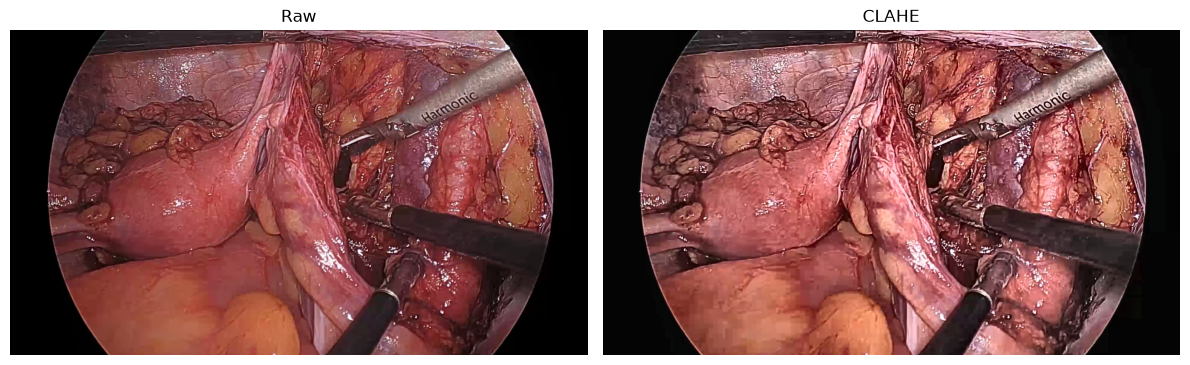

In [10]:
# ------------------------------------------------------------------
# 7b. Before / after CLAHE — visual sanity check
# ------------------------------------------------------------------
sample_path = next(IMG_TRAIN.glob("*"))
raw = cv2.imread(str(sample_path))
corrected = apply_clahe(raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)); axes[0].set_title("Raw"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)); axes[1].set_title("CLAHE"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 8. Domain-specific augmentation: smoke, glare, motion blur

These are plain OpenCV/NumPy image-processing tricks (no GAN, no extra model) that
approximate three failure modes that are common in real laparoscopic video but rare
in a clean training set:

* **Smoke / fog** — cautery smoke fogging the lens → low-frequency blurred white/grey haze overlay.
* **Glare** — bright specular reflections off wet tissue under the scope light → blurred bright blobs.
* **Motion blur** — fast camera or instrument motion → directional blur kernel.

Because these are **pixel-only** transforms (they don't move or resize anything),
the existing YOLO-seg label file for an image is still 100% valid for its
augmented copy — we just copy the `.txt` label alongside the new image.


In [11]:
# ------------------------------------------------------------------
# 8a. Augmentation functions
# ------------------------------------------------------------------

def add_smoke(img, intensity=None):
    # \"\"\"Blurred low-frequency noise blended in as a grey/white haze.\"\"\"
    if intensity is None:
        intensity = np.random.uniform(0.15, 0.45)
    h, w = img.shape[:2]
    noise = np.random.rand(max(1, h // 8), max(1, w // 8)).astype(np.float32)
    noise = cv2.resize(noise, (w, h), interpolation=cv2.INTER_CUBIC)
    noise = cv2.GaussianBlur(noise, (0, 0), sigmaX=np.random.uniform(10, 25))
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-6)
    smoke_layer = np.uint8(np.clip(noise * 255, 180, 255))
    smoke_color = cv2.cvtColor(smoke_layer, cv2.COLOR_GRAY2BGR)
    return cv2.addWeighted(img, 1 - intensity, smoke_color, intensity, 0)


def add_glare(img, num_spots=None, max_radius_frac=0.10, strength=None):
    # \"\"\"Random blurred bright blobs simulating specular highlights.\"\"\"
    h, w = img.shape[:2]
    if num_spots is None:
        num_spots = np.random.randint(1, 4)
    if strength is None:
        strength = np.random.uniform(0.45, 0.75)
    overlay = np.zeros_like(img, dtype=np.uint8)
    last_r = 5
    for _ in range(num_spots):
        cx, cy = np.random.randint(0, w), np.random.randint(0, h)
        r = int(max_radius_frac * min(h, w) * np.random.uniform(0.4, 1.0))
        last_r = max(r, 1)
        cv2.circle(overlay, (cx, cy), last_r, (255, 255, 255), -1)
    overlay = cv2.GaussianBlur(overlay, (0, 0), sigmaX=max(3, last_r / 2))
    return cv2.addWeighted(img, 1.0, overlay, strength, 0)


def add_motion_blur(img, kernel_size=None):
    # \"\"\"Directional (linear) motion blur at a random angle.\"\"\"
    if kernel_size is None:
        kernel_size = np.random.choice([9, 13, 17, 21])
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    kernel[(kernel_size - 1) // 2, :] = 1.0
    angle = np.random.uniform(0, 360)
    M = cv2.getRotationMatrix2D((kernel_size / 2, kernel_size / 2), angle, 1)
    kernel = cv2.warpAffine(kernel, M, (kernel_size, kernel_size))
    kernel = kernel / (kernel.sum() + 1e-6)
    return cv2.filter2D(img, -1, kernel)


def random_domain_augment(img):
    # \"\"\"Apply a random combination of 1-2 of the above effects.\"\"\"
    effects = random.sample([add_smoke, add_glare, add_motion_blur], k=random.choice([1, 1, 2]))
    out = img.copy()
    for fx in effects:
        out = fx(out)
    return out


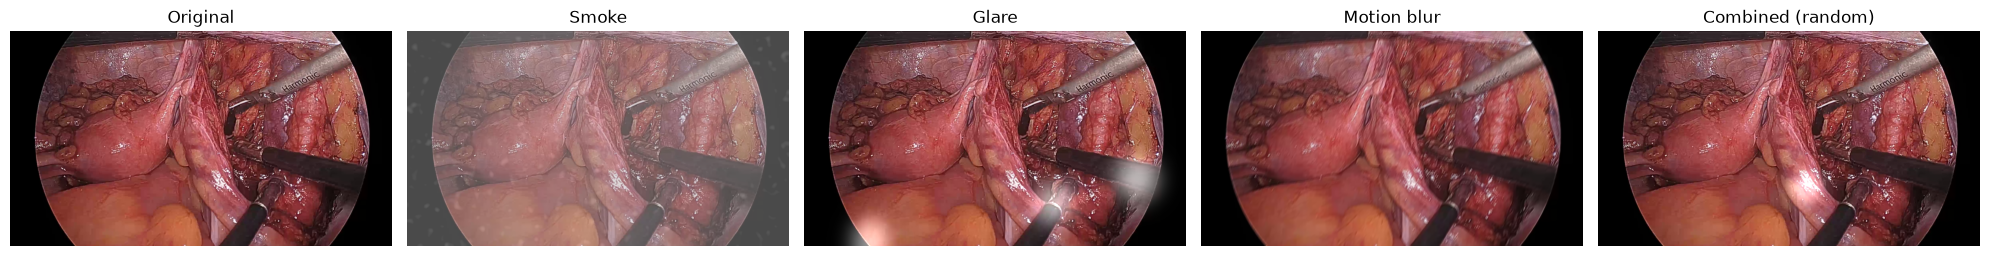

In [12]:
# ------------------------------------------------------------------
# 8b. Visual check — one image, all effects
# ------------------------------------------------------------------
sample_path = next(IMG_TRAIN.glob("*"))
img = cv2.imread(str(sample_path))

variants = {
    "Original": img,
    "Smoke": add_smoke(img),
    "Glare": add_glare(img),
    "Motion blur": add_motion_blur(img),
    "Combined (random)": random_domain_augment(img),
}

fig, axes = plt.subplots(1, len(variants), figsize=(4 * len(variants), 4))
for ax, (title, im) in zip(axes, variants.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [13]:
# ------------------------------------------------------------------
# 8c. Offline augmentation — applied ONLY to a fraction of the TRAIN split
#     (val/test must stay clean/representative of real inference conditions)
# ------------------------------------------------------------------
train_images = list(IMG_TRAIN.glob("*"))
n_to_augment = int(len(train_images) * AUG_FRACTION)
subset = random.sample(train_images, n_to_augment)

for img_path in tqdm(subset, desc=f"Generating {AUG_TAG} copies ({AUG_FRACTION:.0%} of train)"):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    augmented = random_domain_augment(img)
    new_name = f"{AUG_TAG}_{img_path.name}"
    cv2.imwrite(str(IMG_TRAIN / new_name), augmented)

    lbl_path = LBL_TRAIN / f"{img_path.stem}.txt"
    if lbl_path.exists():
        shutil.copy2(lbl_path, LBL_TRAIN / f"{AUG_TAG}_{img_path.stem}.txt")

print(f"Added {n_to_augment} domain-augmented copies to the train split.")
print(f"New train image count: {len(list(IMG_TRAIN.glob('*')))}")


Generating aug copies (25% of train): 100%|██████████| 2388/2388 [10:47<00:00,  3.69it/s]

Added 2388 domain-augmented copies to the train split.
New train image count: 11943


## 9. `data.yaml` for Ultralytics YOLO

Two yaml files are generated: one for the raw split, one for the CLAHE split, so you
can run the exact same training command against either dataset and compare.


In [14]:
# ------------------------------------------------------------------
# 9. Write data.yaml files
# ------------------------------------------------------------------
def write_data_yaml(path, root):
    content = (
        f"path: {root}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"test: images/test\n"
        f"names:\n"
    )
    for i, name in enumerate(yolo_names):
        content += f"  {i}: {name}\n"
    with open(path, "w") as f:
        f.write(content)
    print("Wrote", path)

write_data_yaml(YOLO_ROOT / "data.yaml", str(YOLO_ROOT).replace("\\", "/"))
write_data_yaml(CLAHE_ROOT / "data.yaml", str(CLAHE_ROOT).replace("\\", "/"))


Wrote D:\Study\CDC Project 1\Project\data\yolo\data.yaml
Wrote D:\Study\CDC Project 1\Project\data\yolo_clahe\data.yaml


## 10. Sanity check — draw converted polygons back on an image

If the boxes/masks line up with the anatomy in the image, the COCO → YOLO-seg
conversion is correct.


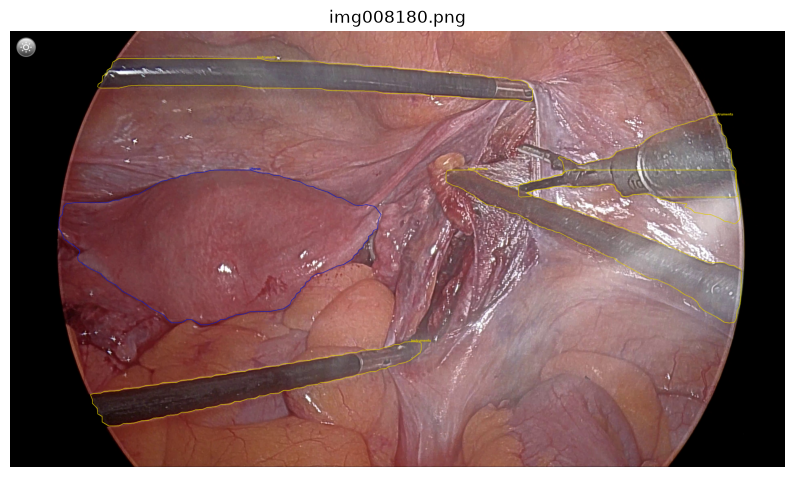

In [15]:
# ------------------------------------------------------------------
# 10. Verify a random train image + its YOLO-seg label overlay correctly
# ------------------------------------------------------------------
sample_img_path = random.choice([p for p in IMG_TRAIN.glob("*") if not p.name.startswith(AUG_TAG)])
sample_lbl_path = LBL_TRAIN / f"{sample_img_path.stem}.txt"

img = cv2.imread(str(sample_img_path))
h, w = img.shape[:2]
vis = img.copy()

colors = {}
if sample_lbl_path.exists():
    with open(sample_lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float64).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            pts = coords.astype(np.int32)
            color = colors.setdefault(cls_id, tuple(int(c) for c in np.random.randint(0, 255, 3)))
            cv2.polylines(vis, [pts], isClosed=True, color=color, thickness=2)
            cv2.putText(vis, yolo_names[cls_id], tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, color, 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(sample_img_path.name)
plt.axis("off")
plt.show()


## 11. Roadmap — what comes *after* preprocessing (not run in this notebook)

These items from your list are **training-time / architecture-time** changes, not
preprocessing, so they belong in your training script, not here. Short notes on
where each one plugs in:

| Item | Where it lives | Effort |
|---|---|---|
| **Attention (CBAM/ECA) in backbone** | Ultralytics lets you define a custom model YAML (`model.yaml`) and drop a `CBAM`/`ECA` module into the backbone layer list, then `YOLO('custom.yaml')`. Ultralytics ships CBAM in `ultralytics/nn/modules`. | Low |
| **Boundary-aware loss** | Add a boundary term (e.g. Sobel/Laplacian edge map difference between predicted and GT mask) to the segmentation loss in the training loop; needs a small custom loss class if you fork Ultralytics' `SegmentationLoss`. | Medium |
| **Multi-scale / tiling for small objects** | Either train at a higher `imgsz` (e.g. 960) if VRAM allows, or pre-tile only the *inference* pipeline (train normally, tile at test time) — full-image tiling for training is usually not worth it at your VRAM budget. | Medium |
| **Focal loss for class imbalance** | Check the class-instance-count table printed in section 3 first — if a class is genuinely rare, Ultralytics' classification loss can be swapped for a focal variant via `cls_pw`/custom loss patch. | Low-Medium |
| **Temporal consistency (optical flow / Kalman)** | Post-processing step applied to the *sequence of predictions* at inference time (e.g. `cv2.calcOpticalFlowFarneback` + a simple Kalman filter per tracked instance) — not part of training data prep. | Medium |
| **Baseline comparison (YOLOv8-seg vs your improved model)** | Train both with the same `data.yaml` and `imgsz`/epochs, then compare mask mAP50-95 with `model.val()`. | Low |

**Suggested training starting point given your 8GB VRAM:**
```powershell
yolo segment train data="D:/Study/CDC Project 1/Project/data/yolo/data.yaml" ^
     model=yolov8s-seg.pt imgsz=640 batch=8 epochs=100 amp=True device=0
```
Start with `yolov8s-seg` (not `m`/`l`) and `imgsz=640` — an 8GB card can be tight with
`yolov8m-seg` at higher resolutions. Increase batch size only if `nvidia-smi` shows
headroom during training.
